## 0. Setup

In [1]:
import os
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile

try:
    import SimpleITK as sitk
except ImportError as exc:
    raise ImportError("3D alignment requires SimpleITK (pip install SimpleITK)") from exc

_REPO = Path.cwd().parent
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))

from registration import sitkalignment

from alignment import caiman_memmap_reader, minmax_scaler

# Display scaling for STD / resliced atlas overlays
QC_VMIN = 50
QC_VMAX = 600
# Atlas / resliced atlas (lower vmax → brighter; was 700 in legacy notebooks)
ATLAS_QC_VMIN = 0
ATLAS_QC_VMAX = 400

# Grids on index previews (§2a atlas planes, §2b func row band)
GRID_STEP_PX = 50
AXIS_TICK_STEP_PX = 200


def imshow_with_index_grid(ax, img, *, vmin=None, vmax=None, cmap="gray", title=None):
    """``imshow`` with grid every ``GRID_STEP_PX`` and ticks every ``AXIS_TICK_STEP_PX``."""
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
    h, w = int(img.shape[0]), int(img.shape[1])
    for x in range(0, w, GRID_STEP_PX):
        ax.axvline(x, color="y", lw=0.5, alpha=0.55)
    for y in range(0, h, GRID_STEP_PX):
        ax.axhline(y, color="y", lw=0.5, alpha=0.55)
    ax.set_xticks(np.arange(0, w, AXIS_TICK_STEP_PX))
    ax.set_yticks(np.arange(0, h, AXIS_TICK_STEP_PX))
    ax.tick_params(labelsize=8)
    if title:
        ax.set_title(title)
    ax.set_xlabel("x (col)")
    ax.set_ylabel("y (row)")


cv2 not available


### Experiment paths

In [9]:
data_folder = Path("/Volumes/Kobi/DOI_animals_good")
fish_name = "elavl3H2BGCaMP6s_8dpf_DOI_0ugml_9_20250924"

exp_folder = data_folder / fish_name
_mcorr_dir = exp_folder / "mcorr_tiff_outputs"

# Whole-stack workflow: all functional planes → one joint 3D pose.
PLANE_INDICES = list(range(11))
ACQUISITION_PLANE = 0  # QC / Elastix reference plane (must be in PLANE_INDICES)
# Optional §1b: replace these stack planes with STD TIFF from mcorr_tiff_outputs (fast; no memmap reload).
STD_TIFF_PLANES = [0]
# Atlas z preview band (§2a only — not used by volume registration).
ATLAS_Z_TOP = 280
ATLAS_Z_BOTTOM = 316

# Optional oblique y-band for §2a atlas previews (unused by volume ROI mapping).
ATLAS_ROW_Y_TOP = 275  # row (y) at z=ATLAS_Z_TOP — dorsal end of tissue
ATLAS_ROW_Y_BOTTOM = 800  # row (y) at z=ATLAS_Z_BOTTOM — ventral end


mapzebrain_img_path = Path("./reference_images/hindbrain/mapzebrain/T_AVG_HuCD.tif")
regions_dir = Path("./reference_images/hindbrain/mapzebrain/mapZebrain__regions")

FUNC_SPACING = sitkalignment.FUNC_SPACING_UM
ATLAS_SPACING = sitkalignment.ATLAS_SPACING_UM
# --- Registration optimizer (RegularStepGradientDescent) ---
REGISTRATION_ITERATIONS = 500  # hard cap; stop early if tolerances met first
REGISTRATION_LEARNING_RATE = 1.0  # initial step length
REGISTRATION_MIN_STEP = 1e-4  # stop when step shrinks below this
REGISTRATION_GRADIENT_TOLERANCE = 1e-4  # stop when gradient norm below this
REGISTRATION_RELAXATION_FACTOR = 0.5  # step reduction on direction change
REGISTRATION_METRIC_SAMPLES = 0.25  # Mattes MI voxel fraction (0–1)
REGISTRATION_HISTOGRAM_BINS = 50  # Mattes MI histogram bins

TRANSFORM_PATH = (
    exp_folder
    / "mcorr_tiff_outputs"
    / f"func_volume_{len(PLANE_INDICES)}planes_to_atlas.tfm"
)

# Elastix fine alignment (fish15): fixed = experiment, moving = volume-resliced atlas (QC plane)
ELASTIX_SAVE_PATH = exp_folder / f"alignment_rev_plane{ACQUISITION_PLANE}"
target_vmin = QC_VMIN
target_vmax = QC_VMAX
source_vmax = ATLAS_QC_VMAX
EXCLUDE_TOP_ROWS_FIXED = 0
ELASTIX_SCALE_PENALTY = 150
ELASTIX_ITERATIONS = (10000, 500)


## 1. Load functional stack (memmap STD → rot90)

All planes in `PLANE_INDICES` are built from **mesmerize-batch** motion-corrected memmaps (`np.nanstd` over time). Each slice is **`np.rot90(..., k=1)`**, scaled × `2**10`, stacked as `(n_planes, y, x)` with **20 µm z spacing**. Optional **§1b** swaps selected planes (e.g. plane 0) with **`mcorr_tiff_outputs/STD*`** without re-running this cell.

Loaded 11 planes (z, y, x) = (11, 1024, 640)
Native plane shape (H, W): (640, 1024)  →  after rot90 k=1: (1024, 640)
Plane order (stack z → acquisition plane): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
QC / Elastix stack index for plane 0: z=0


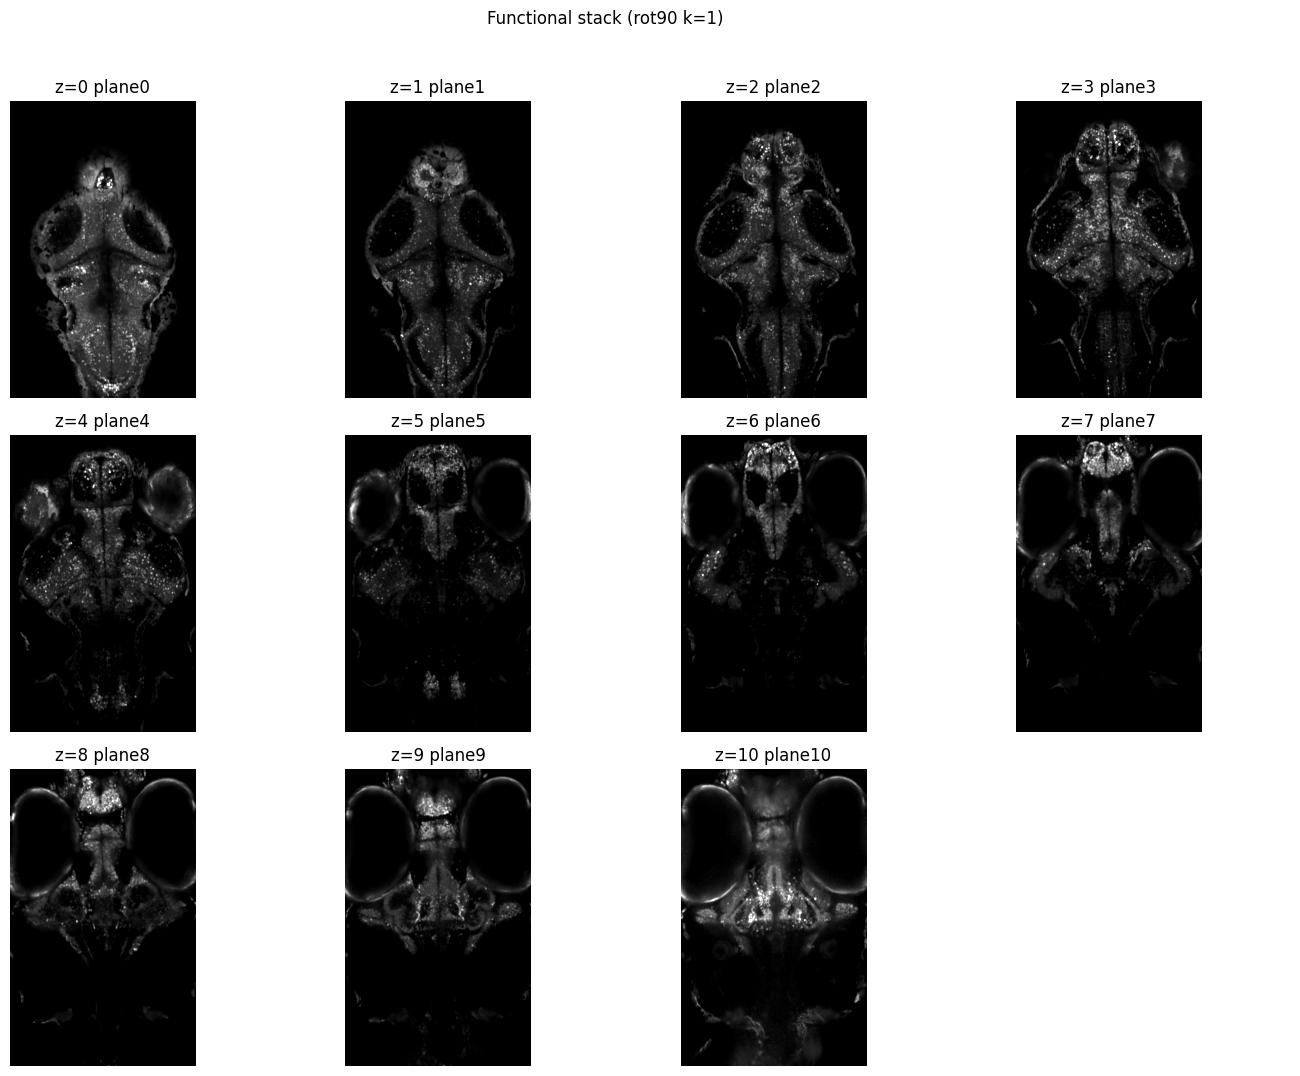

In [ ]:
STD_ROT90_K = 1  # legacy fish07: np.rot90(..., k=1) before registration
INTENSITY_SCALE = 2**10

# --- Build std projections from mesmerize CaImAn memmaps (no per-plane STD TIFFs) ---
batch_path = exp_folder / "mesmerize-batch" / "batch.pickle"
if not batch_path.is_file():
    raise FileNotFoundError(f"Missing mesmerize batch pickle: {batch_path}")

_mbatch_df = pd.read_pickle(batch_path)
_mbatch_df = _mbatch_df[_mbatch_df["algo"] == "mcorr"]

uuid_to_plane = {}
plane_col = None
for candidate in ["plane", "z", "z_plane", "slice", "plane_idx", "plane_index"]:
    if candidate in _mbatch_df.columns:
        plane_col = candidate
        break
if plane_col is not None:
    uuid_to_plane.update(
        {
            str(row.uuid): int(row[plane_col])
            for _, row in _mbatch_df[["uuid", plane_col]].dropna().iterrows()
        }
    )

for _, row in _mbatch_df.iterrows():
    uid = str(row.uuid)
    if uid in uuid_to_plane:
        continue
    for field in ["item_name", "input_movie_path"]:
        if field not in _mbatch_df.columns:
            continue
        text = str(row[field])
        m = re.search(r"img_stack[_\-\s]?(\d+)", text, flags=re.IGNORECASE)
        if m:
            uuid_to_plane[uid] = int(m.group(1))
            break

filenames = set(_mbatch_df.uuid.astype(str))
mmap_items = []
with os.scandir(exp_folder / "mesmerize-batch") as entries:
    for entry in entries:
        if entry.name not in filenames:
            continue
        with os.scandir(entry.path) as subentries:
            for subentry in subentries:
                if not subentry.name.endswith(".mmap") or subentry.name.startswith("._"):
                    continue
                detected_plane = uuid_to_plane.get(entry.name)
                if detected_plane is None:
                    m = re.search(
                        r"(?:^|[_\-\s])(plane|z|slice|img_stack)[_\-\s]?(\d+)(?:[_\-\s]|$)",
                        subentry.path,
                        flags=re.IGNORECASE,
                    )
                    if m:
                        detected_plane = int(m.group(2))
                mmap_items.append((subentry.path, detected_plane, entry.name))

mmap_items.sort(
    key=lambda x: (
        x[1] is None,
        x[1] if x[1] is not None else 10**9,
        x[2],
        x[0],
    )
)

plane_to_mmap = {}
for mmap_path, detected_plane, uid in mmap_items:
    if detected_plane is not None:
        plane_to_mmap[int(detected_plane)] = mmap_path

missing_planes = [int(pl) for pl in PLANE_INDICES if int(pl) not in plane_to_mmap]
if missing_planes:
    raise FileNotFoundError(
        f"No mesmerize memmap for planes {missing_planes}. "
        f"Available: {sorted(plane_to_mmap.keys())}"
    )

slices = []
plane_order = []
native_plane_shape = None
for pl in PLANE_INDICES:
    pl = int(pl)
    img_stack = caiman_memmap_reader(plane_to_mmap[pl], mode="r")
    arr = np.nanstd(img_stack, axis=0).astype(np.float32)
    if native_plane_shape is None:
        native_plane_shape = tuple(int(x) for x in arr.shape)
    elif tuple(arr.shape) != native_plane_shape:
        raise ValueError(
            f"Inconsistent plane shapes: {native_plane_shape} vs {arr.shape} (plane {pl})"
        )
    mx = float(np.nanmax(arr))
    if mx > 0:
        arr = arr / mx
    arr = arr * float(INTENSITY_SCALE)
    if STD_ROT90_K != 0:
        arr = np.ascontiguousarray(np.rot90(arr, k=int(STD_ROT90_K)))
    slices.append(arr)
    plane_order.append(pl)

func_np = np.stack(slices, axis=0)
plane_tiff_items = None
QC_Z_IX = plane_order.index(int(ACQUISITION_PLANE))

print(f"Loaded {func_np.shape[0]} planes (z, y, x) = {func_np.shape}")
print(f"Native plane shape (H, W): {native_plane_shape}  →  after rot90 k={STD_ROT90_K}: {func_np.shape[1:]}")
print("Plane order (stack z → acquisition plane):", plane_order)
print(f"QC / Elastix stack index for plane {ACQUISITION_PLANE}: z={QC_Z_IX}")
if STD_TIFF_PLANES:
    print(f"Run §1b to replace planes {STD_TIFF_PLANES} with STD TIFF (optional).")

func_img = sitkalignment.sitk_volume_from_numpy_zyx(func_np, FUNC_SPACING)

_ncols = min(4, len(plane_order))
_nrows = int(np.ceil(len(plane_order) / _ncols))
fig, axes = plt.subplots(_nrows, _ncols, figsize=(3.5 * _ncols, 3.5 * _nrows))
axes = np.atleast_1d(axes).ravel()
for z_ix, pl in enumerate(plane_order):
    axes[z_ix].imshow(func_np[z_ix], cmap="gray", vmin=QC_VMIN, vmax=QC_VMAX)
    axes[z_ix].set_title(f"z={z_ix} plane{pl}")
    axes[z_ix].axis("off")
for ax in axes[len(plane_order) :]:
    ax.axis("off")
plt.suptitle(f"Functional stack (rot90 k={STD_ROT90_K})", y=1.02)
plt.tight_layout()
plt.show()


### 1b. Replace selected planes with STD TIFF (optional)

Run this **after §1** if `func_np` is already in memory. Swaps planes in `STD_TIFF_PLANES` with `mcorr_tiff_outputs/STD*` and rebuilds `func_img` — no memmap reload.

Replaced stack z=0 plane0 with STD TIFF STD_mcorr_plane0_idx1_strides(160, 160)_overlaps(60, 60)_maxshifts(10, 10)_maxdev10.tif


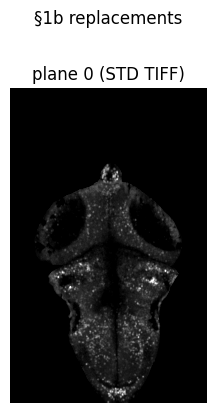

In [10]:
# Requires §1: func_np, plane_order, native_plane_shape
if "func_np" not in globals() or "plane_order" not in globals():
    raise RuntimeError("Run §1 first (defines func_np and plane_order).")

_std_tiff_planes = [int(p) for p in STD_TIFF_PLANES]
if not _std_tiff_planes:
    print("STD_TIFF_PLANES is empty — nothing to replace.")
else:
    _replacements = []
    for pl in _std_tiff_planes:
        if pl not in plane_order:
            raise ValueError(f"plane {pl} not in plane_order {plane_order}")
        z_ix = plane_order.index(pl)
        _items = sitkalignment.discover_std_plane_tiffs(_mcorr_dir, [pl])
        _vol, _, _native = sitkalignment.load_std_functional_volume(
            _items,
            scale_max=True,
            intensity_scale=INTENSITY_SCALE,
            rot90_k=STD_ROT90_K,
        )
        if _native != native_plane_shape:
            raise ValueError(
                f"STD TIFF native shape {_native} != stack {native_plane_shape} (plane {pl})"
            )
        if _vol[0].shape != func_np[z_ix].shape:
            raise ValueError(
                f"STD TIFF rot90 shape {_vol[0].shape} != func_np[{z_ix}] {func_np[z_ix].shape}"
            )
        func_np[z_ix] = _vol[0]
        _replacements.append((pl, z_ix, _items[0][1].name))
    func_np = np.ascontiguousarray(func_np, dtype=np.float32)
    func_img = sitkalignment.sitk_volume_from_numpy_zyx(func_np, FUNC_SPACING)
    for pl, z_ix, name in _replacements:
        print(f"Replaced stack z={z_ix} plane{pl} with STD TIFF {name}")

    _n = len(_replacements)
    fig, axes = plt.subplots(1, _n, figsize=(4 * _n, 4))
    axes = np.atleast_1d(axes).ravel()
    for ax, (pl, z_ix, _) in zip(axes, _replacements):
        ax.imshow(func_np[z_ix], cmap="gray", vmin=QC_VMIN, vmax=QC_VMAX)
        ax.set_title(f"plane {pl} (STD TIFF)")
        ax.axis("off")
    plt.suptitle("§1b replacements", y=1.02)
    plt.tight_layout()
    plt.show()

## 2. Load atlas → §2a set `ATLAS_ROW_Y_*` → §3 registration


In [11]:
atlas_np = np.asarray(tifffile.imread(mapzebrain_img_path), dtype=np.float32)
atlas_img = sitkalignment.sitk_volume_from_numpy_zyx(atlas_np, ATLAS_SPACING)

_zlo, _zhi = min(ATLAS_Z_BOTTOM, ATLAS_Z_TOP), max(ATLAS_Z_BOTTOM, ATLAS_Z_TOP)
print(f"Atlas shape (z, y, x): {atlas_np.shape}, spacing {ATLAS_SPACING} µm")
print(f"Registration slab z={_zlo}…{_zhi}  |  preview planes z={ATLAS_Z_TOP} (top), z={ATLAS_Z_BOTTOM} (bottom)")


Atlas shape (z, y, x): (359, 974, 597), spacing (1.0, 1.0, 1.0) µm
Registration slab z=280…316  |  preview planes z=280 (top), z=316 (bottom)


### 2a. Preview atlas reference planes — set oblique y-band

Mark **atlas row (y)** where tissue starts on the **top** z-slice (`ATLAS_ROW_Y_TOP`) and ends on the **bottom** z-slice (`ATLAS_ROW_Y_BOTTOM`). Grid every 50 px; ticks every 200 px. The oblique merge uses **only** these atlas bounds (not experiment-plane rows).


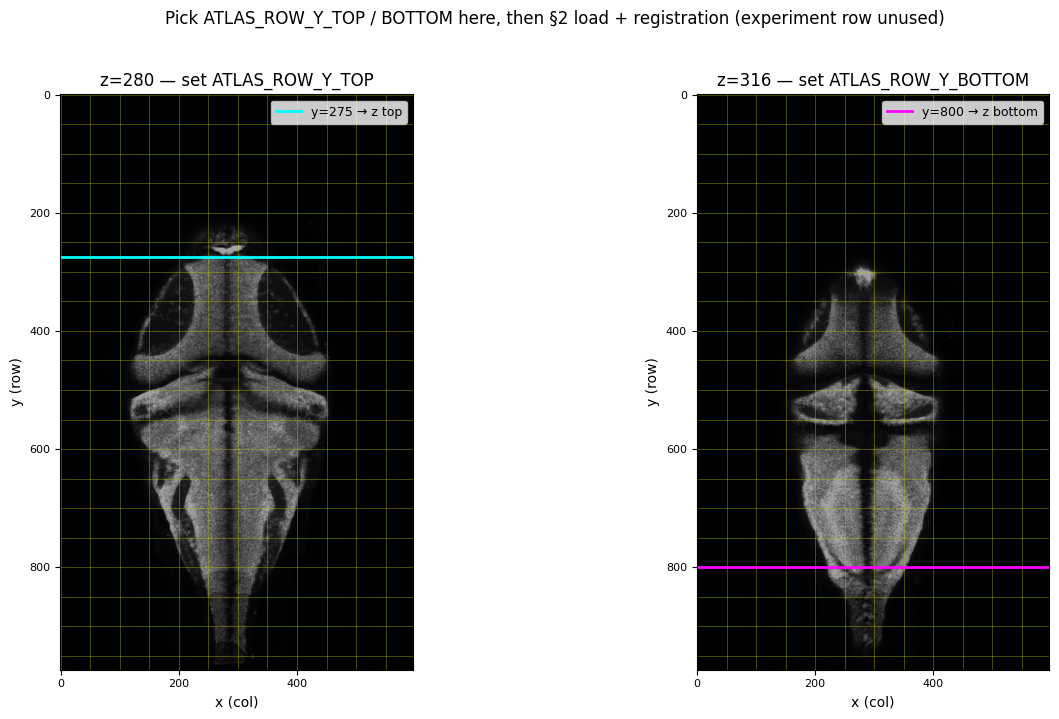

ATLAS_ROW_Y_TOP=275 → z=280
ATLAS_ROW_Y_BOTTOM=800 → z=316


In [12]:
_ay_top = 0 if ATLAS_ROW_Y_TOP is None else int(ATLAS_ROW_Y_TOP)
_ay_bot = (atlas_np.shape[1] - 1) if ATLAS_ROW_Y_BOTTOM is None else int(ATLAS_ROW_Y_BOTTOM)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
imshow_with_index_grid(
    axes[0],
    atlas_np[ATLAS_Z_TOP],
    vmin=ATLAS_QC_VMIN,
    vmax=ATLAS_QC_VMAX,
    title=f"z={ATLAS_Z_TOP} — set ATLAS_ROW_Y_TOP",
)
axes[0].axhline(_ay_top, color="cyan", lw=2, label=f"y={_ay_top} → z top")
imshow_with_index_grid(
    axes[1],
    atlas_np[ATLAS_Z_BOTTOM],
    vmin=ATLAS_QC_VMIN,
    vmax=ATLAS_QC_VMAX,
    title=f"z={ATLAS_Z_BOTTOM} — set ATLAS_ROW_Y_BOTTOM",
)
axes[1].axhline(_ay_bot, color="magenta", lw=2, label=f"y={_ay_bot} → z bottom")
for ax in axes:
    ax.legend(loc="upper right", fontsize=9)
plt.suptitle(
    "Pick ATLAS_ROW_Y_TOP / BOTTOM here, then §2 load + registration (experiment row unused)",
    y=1.02,
)
plt.tight_layout()
plt.show()

print(f"ATLAS_ROW_Y_TOP={_ay_top} → z={ATLAS_Z_TOP}")
print(f"ATLAS_ROW_Y_BOTTOM={_ay_bot} → z={ATLAS_Z_BOTTOM}")


## 3. Whole-stack 3D volume registration

**One 3D affine:** fixed = full functional stack (`func_np`, 20 µm z spacing), moving = mapZebrain atlas. Tilt and each plane's depth fall out of the single pose; every ROI maps through the same `func_to_atlas_T`.

In [13]:
%%time
# If registration drifts, seed initial_transform (e.g. Euler3D) before the affine:
# initial = sitk.CenteredTransformInitializer(...); then pass to register_*.

func_to_atlas_T, atlas_resliced, _func_np, _plane_order, _native_plane_shape, reg_info = (
    sitkalignment.register_functional_volume_to_mapzebrain(
        atlas_np,
        func_np_zyx=func_np,
        func_spacing=FUNC_SPACING,
        atlas_spacing=ATLAS_SPACING,
        save_transform_path=TRANSFORM_PATH,
        number_of_iterations=REGISTRATION_ITERATIONS,
        learning_rate=REGISTRATION_LEARNING_RATE,
        metric_sampling_percentage=REGISTRATION_METRIC_SAMPLES,
        number_of_histogram_bins=REGISTRATION_HISTOGRAM_BINS,
    )
)
func_img = sitkalignment.sitk_volume_from_numpy_zyx(func_np, FUNC_SPACING)

print("mode:", reg_info.get("mode"))
print("func shape:", reg_info.get("func_shape_zyx"))
print("atlas shape:", reg_info.get("atlas_shape_zyx"))
print("stop:", reg_info["stop"])
print("metric:", reg_info["metric"])
print("saved transform:", TRANSFORM_PATH)


mode: volume
func shape: (11, 1024, 640)
atlas shape: (359, 974, 597)
stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 275 iterations. Gradient magnitude (8.18221e-07) is less than gradient magnitude tolerance (1e-06).
metric: -0.22580899556915388
saved transform: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_8dpf_DOI_0ugml_9_20250924/mcorr_tiff_outputs/func_volume_11planes_to_atlas.tfm
CPU times: user 8min 45s, sys: 16.9 s, total: 9min 2s
Wall time: 1min 8s


### Resliced atlas preview

`atlas_resliced` is mapZebrain sampled onto the **functional stack grid** (same shape as `func_np`) using the joint 3D transform. Inspect a few z-slices here before the experiment overlay in §4.

atlas_resliced shape: (11, 1024, 640), mode: volume


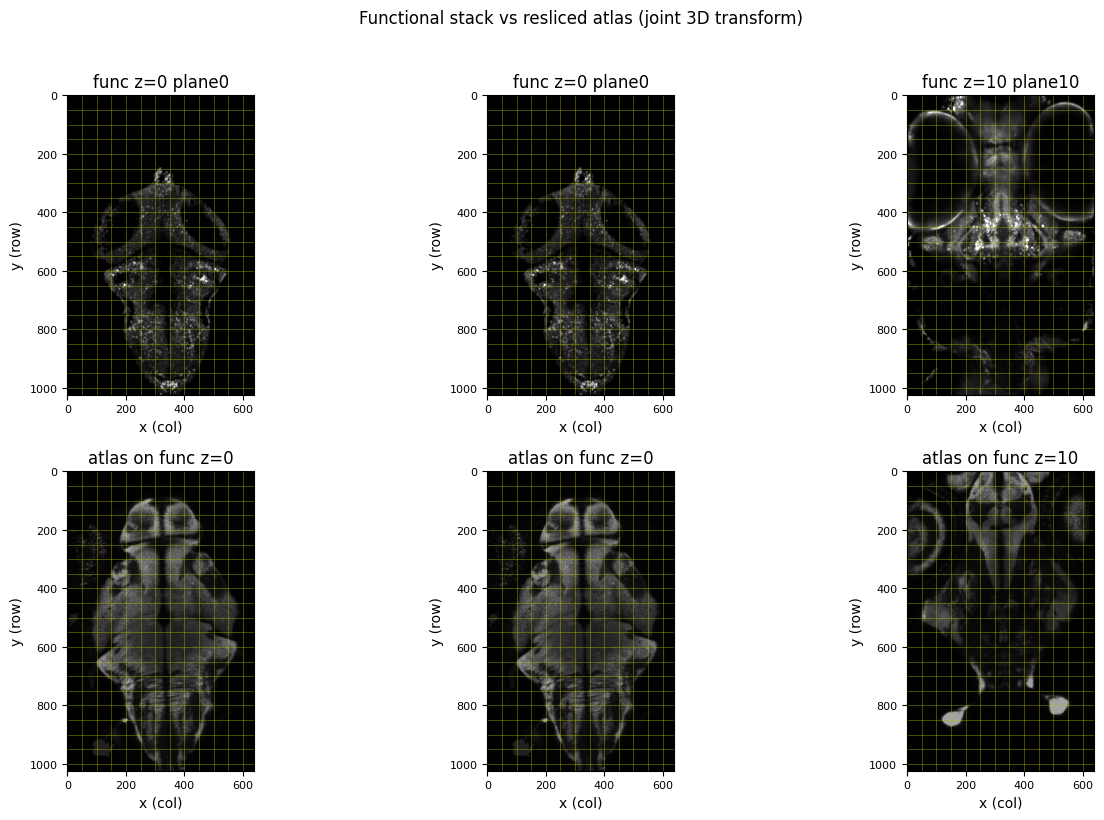

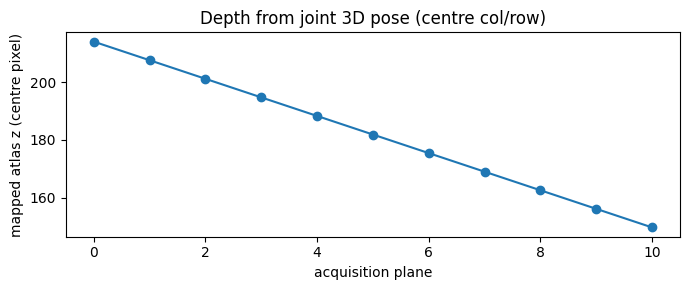

In [14]:
print(f"atlas_resliced shape: {atlas_resliced.shape}, mode: {reg_info.get('mode')}")

_preview_z = [0, QC_Z_IX, len(plane_order) - 1]
fig, axes = plt.subplots(2, len(_preview_z), figsize=(4.5 * len(_preview_z), 8))
for j, z_ix in enumerate(_preview_z):
    pl = plane_order[z_ix]
    imshow_with_index_grid(
        axes[0, j],
        func_np[z_ix],
        vmin=QC_VMIN,
        vmax=QC_VMAX,
        title=f"func z={z_ix} plane{pl}",
    )
    imshow_with_index_grid(
        axes[1, j],
        atlas_resliced[z_ix],
        vmin=ATLAS_QC_VMIN,
        vmax=ATLAS_QC_VMAX,
        title=f"atlas on func z={z_ix}",
    )
plt.suptitle("Functional stack vs resliced atlas (joint 3D transform)", y=1.02)
plt.tight_layout()
plt.show()

# Per-plane mapped atlas z at stack centre (volume pose, not oblique band)
_col = func_np.shape[2] // 2
_row = func_np.shape[1] // 2
_mapped_z = []
for z_ix, pl in enumerate(plane_order):
    _, _, az = sitkalignment.func_index_to_atlas_continuous_index(
        _col, _row, z_ix, func_img, func_to_atlas_T, atlas_img
    )
    _mapped_z.append(float(az))
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(plane_order, _mapped_z, "o-")
ax.set_xlabel("acquisition plane")
ax.set_ylabel("mapped atlas z (centre pixel)")
ax.set_title("Depth from joint 3D pose (centre col/row)")
plt.tight_layout()
plt.show()


## 4. Elastix: resliced atlas → experiment (`brain_alignment_fish15`)

After §3 volume registration, **`register_image2`** refines alignment on the **QC plane** (`ACQUISITION_PLANE`):
- **Fixed** = experiment (`plot_img` = `func_np[QC_Z_IX]` after rot90)
- **Moving** = **`atlas_resliced[QC_Z_IX]`** (same grid as experiment)

Transforms are saved under **`ELASTIX_SAVE_PATH`** for inverse point mapping like fish15.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


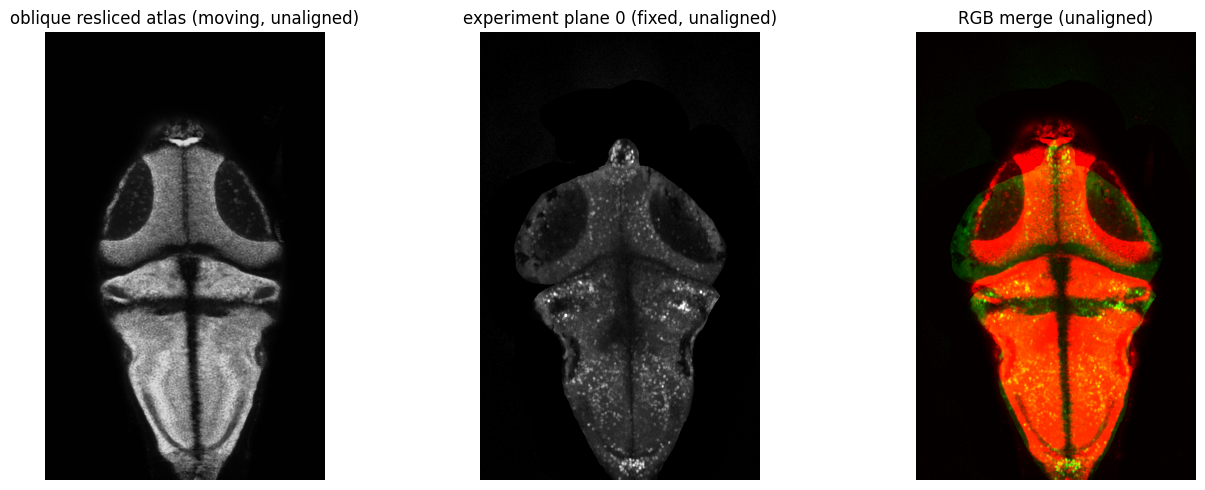

In [9]:
# Unaligned pair on the functional grid (native rot90 STD shape; no 1024 embed).
ELASTIX_SAVE_PATH = exp_folder / f"alignment_rev_plane{ACQUISITION_PLANE}"
target_vmin = 0
target_vmax = 600
source_vmax = 300
EXCLUDE_TOP_ROWS_FIXED = 0
ELASTIX_SCALE_PENALTY = 150
ELASTIX_ITERATIONS = (10000, 500)



plot_img = np.asarray(func_np[QC_Z_IX], dtype=np.float32)
source_img = np.asarray(atlas_resliced[QC_Z_IX], dtype=np.float32)
if plot_img.shape != source_img.shape:
    raise ValueError(f"Shape mismatch plot {plot_img.shape} vs resliced {source_img.shape}")

if EXCLUDE_TOP_ROWS_FIXED:
    plot_img = plot_img.copy()
    plot_img[:EXCLUDE_TOP_ROWS_FIXED, :] = 0

registration_fixed_mask = sitkalignment.registration_mask_from_exclusions(
    plot_img.shape, exclude_top=EXCLUDE_TOP_ROWS_FIXED
)
registration_moving_mask = np.ones(source_img.shape, dtype=np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
ax[0].imshow(source_img, cmap="gray", vmin=ATLAS_QC_VMIN, vmax=source_vmax)
ax[0].set_title("volume-resliced atlas (moving, unaligned)")
ax[1].imshow(plot_img, cmap="gray", vmin=target_vmin, vmax=target_vmax)
ax[1].set_title(f"experiment plane {plane_order[QC_Z_IX]} (fixed, unaligned)")
merge = np.zeros((*plot_img.shape, 3))
merge[:, :, 0] = 2 * source_img / max(float(source_img.max()), 1.0)
merge[:, :, 1] = 2 * plot_img / max(float(plot_img.max()), 1.0)
ax[2].imshow(merge)
ax[2].set_title("RGB merge (unaligned)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()


In [10]:
%%time
# fish15: minmax_scaler + register_image2 (fixed = experiment, moving = resliced atlas).
_reg_plot = minmax_scaler(plot_img, vmin=target_vmin, vmax=target_vmax)
_reg_source = minmax_scaler(source_img, vmin=0, vmax=source_vmax)

atlas_registered = sitkalignment.register_image2(
    _reg_plot,
    _reg_source,
    ELASTIX_SAVE_PATH,
    scalePenalty=ELASTIX_SCALE_PENALTY,
    iterations=ELASTIX_ITERATIONS,
    fixed_mask=registration_fixed_mask,
    moving_mask=registration_moving_mask,
)
atlas_registered = np.asarray(atlas_registered, dtype=np.float32)
print("Elastix output shape:", atlas_registered.shape)
print("Saved transforms:", ELASTIX_SAVE_PATH)


Installing all components.
InstallingComponents was successful.

ELASTIX version: 5.0.1
Command line options from ElastixBase:
-fMask    unspecified, so no fixed mask used
-mMask    unspecified, so no moving mask used
-out      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_8dpf_DOI_0ugml_9_20250924/alignment_rev_plane0/
-threads  unspecified, so all available threads are used
Command line options from TransformBase:
-t0       unspecified, so no initial transform used

Reading images...
Reading images took 0 ms.

  A default pyramid schedule is used.
  A default pyramid schedule is used.
  The default value "false" is used instead.
  The default value "GeometricalCenter" is used instead.
Transform parameters are initialized as: [1, 0, 0, 1, 0, 0]
InitializeTransform took 0.00s
Scales are estimated automatically.
Scales for transform parameters are: [34128.25, 87376.25, 34128.25, 87376.25, 1, 1]
Initialization of all components (before registration) took: 3 ms.
Preparation of the image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


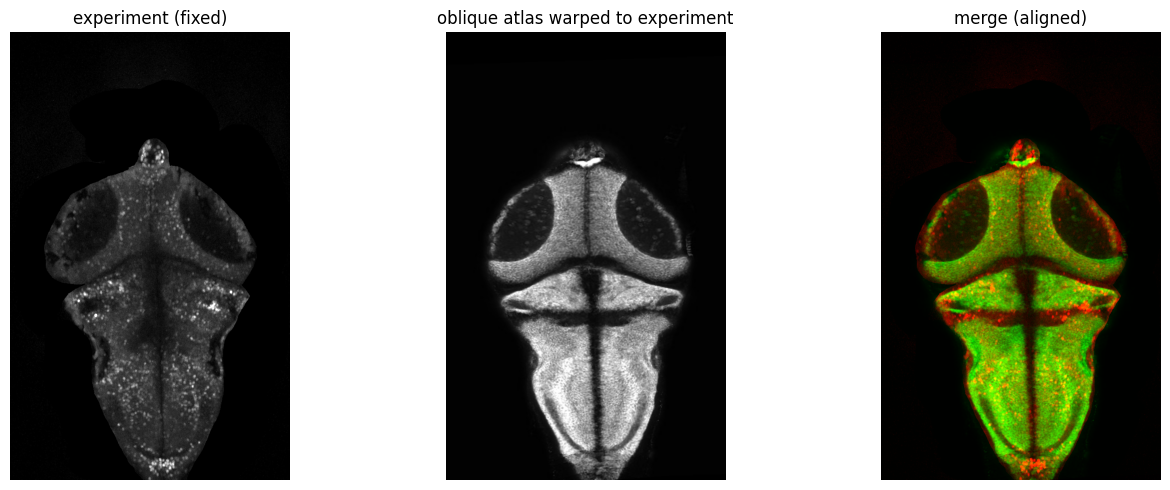

In [11]:
# Post-registration QC (fish15 three-panel merge).
target_img = plot_img
fig, ax = plt.subplots(1, 3, figsize=(14, 5))
ax[0].imshow(target_img, cmap="gray", vmin=target_vmin, vmax=target_vmax)
ax[0].set_title("experiment (fixed)")
ax[1].imshow(atlas_registered, cmap="gray", vmin=0, vmax=source_vmax)
ax[1].set_title("volume atlas warped to experiment")
merge = np.zeros((*target_img.shape, 3))
merge[:, :, 0] = 3 * target_img / max(float(target_img.max()), 1.0)
merge[:, :, 1] = 1 * atlas_registered / max(float(atlas_registered.max()), 1.0)
ax[2].imshow(merge)
ax[2].set_title("merge (aligned)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()


## 5. QC overlay (pre-Elastix volume reslice vs Elastix-warped atlas)

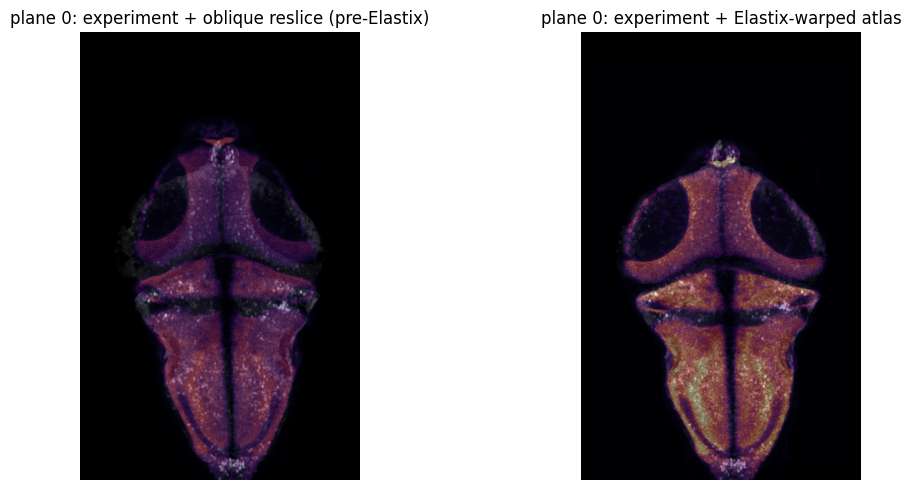

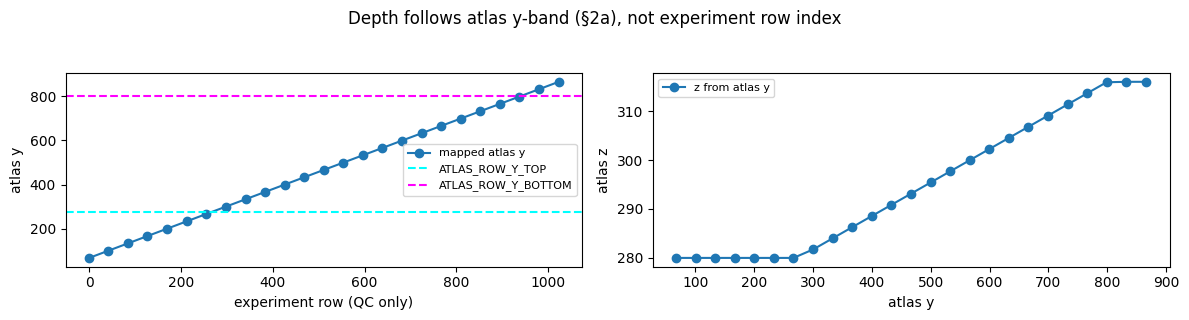

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(func_np[QC_Z_IX], cmap="gray", vmin=QC_VMIN, vmax=QC_VMAX)
axes[0].imshow(atlas_resliced[QC_Z_IX], cmap="magma", vmin=0, vmax=ATLAS_QC_VMAX, alpha=0.45)
axes[0].set_title(f"plane {plane_order[QC_Z_IX]}: experiment + volume reslice (pre-Elastix)")
axes[0].axis("off")

axes[1].imshow(func_np[QC_Z_IX], cmap="gray", vmin=QC_VMIN, vmax=QC_VMAX)
axes[1].imshow(atlas_registered, cmap="magma", vmin=0, vmax=source_vmax, alpha=0.45)
axes[1].set_title(f"plane {plane_order[QC_Z_IX]}: experiment + Elastix-warped atlas")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 6. Map ROI centers through the same transform

COMs are in **raw STD** coordinates `(col, row)` (as in `temporal_pack_compact.h5`). Converted with **`STD_ROT90_K`**, then mapped with the **joint 3D volume** transform (`func_index_to_atlas_continuous_index`).

For the current plane: table of atlas indices + inverse-transformed mapzebrain COMs, and a three-panel overlay (experiment → elastix mapzebrain → atlas slice at median mapped z).

In [ ]:
def func_com_to_atlas_voxel(col, row, plane_number):
    """Raw STD (col, row) + acquisition plane → atlas continuous index (x, y, z)."""
    if STD_ROT90_K != 0:
        col, row = sitkalignment.native_xy_to_rot90_xy(
            col, row, native_plane_shape, rot90_k=STD_ROT90_K
        )
    z_ix = sitkalignment.func_plane_number_to_stack_index(plane_number, plane_order)
    ax, ay, az = sitkalignment.func_index_to_atlas_continuous_index(
        col,
        row,
        z_ix,
        func_img,
        func_to_atlas_T,
        atlas_img,
    )
    return ax, ay, az


# --- ROI table: raw STD COM → atlas (all planes) + plane overlay (experiment / mapzebrain) ---
W_EMBED = 1024

if "com_to_target_xy" not in globals():
    def com_to_target_xy(x, y):
        px, py = float(x), float(y)
        ox, oy = py, W_EMBED - 1 - px
        return (ox, oy)


def _unpack_com(c):
    v = np.asarray(c, dtype=float).ravel()
    if v.size < 2:
        raise ValueError(f"COM must have at least 2 values, got {c!r}")
    return float(v[0]), float(v[1])


_h5_candidates = [
    exp_folder / "temporal_pack_compact.h5",
    data_folder / "temporal_pack_compact.h5",
]
_h5 = next((p for p in _h5_candidates if p.is_file()), None)
if _h5 is None:
    raise FileNotFoundError(
        "temporal_pack_compact.h5 not found. Tried:\n  "
        + "\n  ".join(str(p) for p in _h5_candidates)
    )

fish_id = int(fish_name.split("_")[-2])
_plane = int(globals().get("plane", globals().get("selected_plane", PLANE_INDICES[0])))

_tdf = df.copy() if "df" in globals() else pd.read_hdf(_h5)
_fish_mask = _tdf["fish_id"] == fish_id

for _col in ("atlas_x", "atlas_y", "atlas_z"):
    if _col not in _tdf.columns:
        _tdf[_col] = np.nan

for _ix, row in _tdf.loc[_fish_mask].iterrows():
    c = np.asarray(row["com"], dtype=float).ravel()
    if c.size < 2:
        _tdf.loc[_ix, ["atlas_x", "atlas_y", "atlas_z"]] = (np.nan, np.nan, np.nan)
        continue
    try:
        ax, ay, az = func_com_to_atlas_voxel(c[0], c[1], int(row["plane"]))
        _tdf.loc[_ix, ["atlas_x", "atlas_y", "atlas_z"]] = (ax, ay, az)
    except ValueError:
        _tdf.loc[_ix, ["atlas_x", "atlas_y", "atlas_z"]] = (np.nan, np.nan, np.nan)

df = _tdf
_roi_plane = _tdf[(_tdf["fish_id"] == fish_id) & (_tdf["plane"] == _plane)].copy()

if not len(_roi_plane):
    print(f"No ROIs for fish_id={fish_id}, plane={_plane} in {_h5}")
else:
    if "plot_img" not in globals():
        raise ValueError(
            "No target image for overlay. Rerun the unaligned visualization cell (defines plot_img)."
        )

    save_path = exp_folder.joinpath(f"alignment_rev_plane{_plane}")
    if not save_path.is_dir():
        raise FileNotFoundError(
            f"Elastix output not found: {save_path}. Run the registration cell first."
        )

    _all_pts = [com_to_target_xy(*_unpack_com(c)) for c in _roi_plane["com"]]
    rev_points = sitkalignment.transform_points(Path(save_path), _all_pts)

    _COM_MAP_COL = "com_aligned_mapzebrain"
    if _COM_MAP_COL not in _tdf.columns:
        _tdf[_COM_MAP_COL] = pd.Series(index=_tdf.index, dtype=object)
    for _ix, _rp in zip(_roi_plane.index, rev_points):
        _tdf.at[_ix, _COM_MAP_COL] = (float(_rp[0]), float(_rp[1]))
    df = _tdf
    _roi_plane = _tdf.loc[_roi_plane.index].copy()

    _display_cols = [
        "plane",
        "com",
        "atlas_x",
        "atlas_y",
        "atlas_z",
        _COM_MAP_COL,
    ]
    display(_roi_plane[_display_cols])

    _tvmin = globals().get("target_vmin", 0)
    _tvmax = globals().get("target_vmax", 1000)
    _src_vmax = globals().get("source_vmax", 1000)
    _n = len(_all_pts)
    _rng = np.random.default_rng()
    _pt_colors = _rng.random((_n, 3)) if _n else np.empty((0, 3))

    xs_e = np.array([p[0] for p in _all_pts], dtype=float)
    ys_e = np.array([p[1] for p in _all_pts], dtype=float)
    xs_m = np.array([p[0] for p in rev_points], dtype=float)
    ys_m = np.array([p[1] for p in rev_points], dtype=float)
    xs_a = _roi_plane["atlas_x"].to_numpy(dtype=float)
    ys_a = _roi_plane["atlas_y"].to_numpy(dtype=float)
    zs_a = _roi_plane["atlas_z"].to_numpy(dtype=float)
    _valid_a = np.isfinite(xs_a) & np.isfinite(ys_a) & np.isfinite(zs_a)
    _atlas_z_ix = int(np.round(np.nanmedian(zs_a[_valid_a]))) if _valid_a.any() else ATLAS_Z_TOP
    _atlas_z_ix = int(np.clip(_atlas_z_ix, 0, atlas_np.shape[0] - 1))

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    axes[0].imshow(plot_img, cmap="gray", vmin=_tvmin, vmax=_tvmax)
    axes[0].scatter(xs_e, ys_e, c=_pt_colors, s=10, alpha=0.85, linewidths=0)
    axes[0].set_title(f"Experiment — {len(_all_pts)} COMs (fish {fish_id}, plane {_plane})")
    axes[0].axis("off")

    axes[1].imshow(source_img, cmap="gray", vmin=0, vmax=_src_vmax)
    axes[1].scatter(xs_m, ys_m, c=_pt_colors, s=10, alpha=0.85, linewidths=0)
    axes[1].set_title(f"Mapzebrain (resliced) — inverse-transformed COMs")
    axes[1].axis("off")

    axes[2].imshow(
        atlas_np[_atlas_z_ix],
        cmap="gray",
        vmin=ATLAS_QC_VMIN,
        vmax=ATLAS_QC_VMAX,
    )
    if _valid_a.any():
        axes[2].scatter(xs_a[_valid_a], ys_a[_valid_a], c=_pt_colors[_valid_a], s=10, alpha=0.85, linewidths=0)
    axes[2].set_title(f"Atlas z={_atlas_z_ix} — mapped COMs (median z of plane)")
    axes[2].axis("off")

    fig.suptitle(
        f"ROI overlay — matching colors = same ROI (rot90 CCW, x in experiment panel)",
        fontsize=11,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


### Region labels at atlas voxel (optional)

In [ ]:
# Label by querying mapZebrain region masks at rounded atlas indices (coarse z).
LOAD_REGION_MASKS = False  # set True to scan region TIFFs (slow first time)

if LOAD_REGION_MASKS:
    _region_paths = sitkalignment.list_mapzebrain_region_mask_paths(regions_dir)
    print(f"{len(_region_paths)} region masks under {regions_dir}")
    _roi_fish = df[df["fish_id"] == fish_id] if "df" in globals() else pd.DataFrame()
    if len(_roi_fish):
        _labels = []
        for _, row in _roi_fish.iterrows():
            if pd.isna(row.get("atlas_x")):
                _labels.append([])
                continue
            names = sitkalignment.region_names_at_atlas_index(
                row["atlas_x"], row["atlas_y"], row["atlas_z"], _region_paths
            )
            _labels.append(names)
        _roi_fish = _roi_fish.copy()
        _roi_fish["region_atlas"] = _labels
        display(_roi_fish[["plane", "atlas_z", "region_atlas"]].head(8))
else:
    print("Set LOAD_REGION_MASKS=True to assign region names from mapZebrain__regions")


## 7. Reload saved transform (optional)

In [ ]:
# func_to_atlas_T = sitk.ReadTransform(str(TRANSFORM_PATH))
# print("Loaded", TRANSFORM_PATH)
